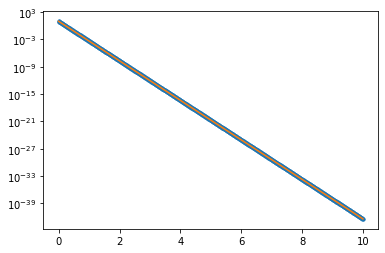

In [4]:
# impulse response of a simple cont. LTI
cs = signal.lti([10], [1, 10])
t, sig = cs.impulse(T = arange(0, 10, 0.01))    
plot(t, sig, '.')
yscale('log')
plot(t, 10*exp(-10*t))

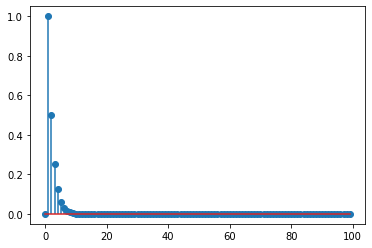

In [37]:
ds = signal.dlti([1], [1, -0.5])
n, h = ds.impulse()
stem(n, h[0], 'o')
show()

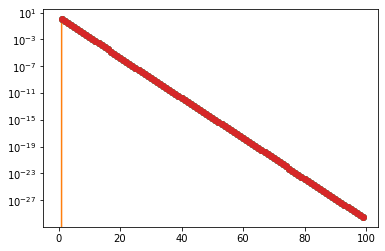

In [38]:
plot(n, h[0], 'o')
ht = zeros(len(h[0]))
ht[1:] = 0.5**arange(len(h[0]) - 1)
plot(n, ht,'.-')
plot(n, h[0], 'o')
yscale('log')
plot(n, h[0], 'o')
show()

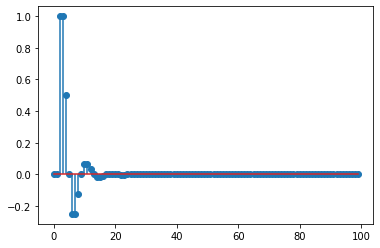

In [39]:
w, h = signal.freqz([1], [1, -1, 0.5])
ds = signal.dlti([1], [1, -1, 0.5])
n, hn = ds.impulse()
stem(n, hn[0])
show()

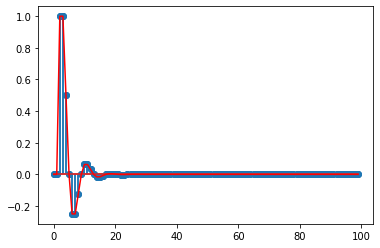

In [42]:
ds = signal.dlti([1], [1, -1, 0.5])
n, h = ds.impulse()
stem(n, h[0], 'o')
ht = zeros(len(h[0]))
# see from last week analytical approach
ht[1:] = (lambda n: 2*sin((n-1)*pi/4)/sqrt(2)**(n-1))(arange(1, len(h[0])))
stem(n, h[0])
plot(n, ht, 'r-')

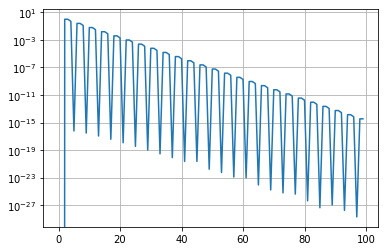

In [46]:
# to illustrate that it is an exponentially decaying oscillation
semilogy(n, abs(ht))
grid()

In [47]:
# to_zpk() method of an LTI system returns the zeros and poles
print(ds.to_zpk())

ZerosPolesGainDiscrete(
array([], dtype=float64),
array([0.5+0.5j, 0.5-0.5j]),
1.0,
dt: True
)


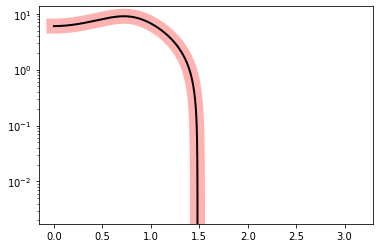

In [48]:
# to verify the frequency response (magnitude and phase)
w, H = ds.freqresp() # complex freq. response including both
# compare freq. response and the output of the bode() method
w, gain, phase = ds.bode(w = w)
semilogy(w, 20*log10(abs(H)), 'r-', linewidth=15, alpha=0.3)
semilogy(w, gain, 'k-', linewidth=2, alpha=1)